<a href="https://colab.research.google.com/github/Sonukumar364/myOwnproject/blob/satelitecv/Clustering_Based_Segmentation_Techniques_for_Satellite_Image_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Setting Up Earth Engine and Importing Libraries**

In [ ]:
!pip install earthengine-api
!pip install geemap

import ee
import geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.2 MB/s eta 0:00:00


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

In [ ]:
p_id = 'zenithh'
ee.Authenticate()
ee.Initialize(project=p_id)

In [ ]:
Map = geemap.Map()
Map.add_basemap('SATELLITE')

In [ ]:
image = cv2.imread('23.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


**A Google Earth Engine Map object is created with a satellite basemap. The AOI is defined around India, with coordinates that cover a zoomed-in area.**


A Landsat 8 image collection is selected and filtered for images in 2020 that cover the specified AOI. We calculate the median to get a single representative image for the year. SR_B4, SR_B3, and SR_B2 bands correspond to red, green, and blue, respectively.

In [ ]:
# aoi = ee.Geometry.Rectangle([18.450, -34.050, 18.470, -34.030])

aoi = ee.Geometry.Rectangle([85.1, 25.57, 85.2, 25.62])


landsat = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
           .filterBounds(aoi) \
           .filterDate('2020-01-01', '2020-12-31') \
           .median()

rgb_image = landsat.select(['SR_B4', 'SR_B3', 'SR_B2'])

Map = geemap.Map()
Map.centerObject(aoi, 14)
Map.addLayer(rgb_image, {'bands': ['SR_B4', 'SR_B3', 'SR_B2'], 'min': 0, 'max': 3000}, 'Landsat RGB')

**The mask_clouds function removes cloud and shadow interference using bit masks. The cloud-free image is returned as landsat_clean.**

In [ ]:

def mask_clouds(image):

    cloud_shadow_bit_mask = (1 << 4)
    clouds_bit_mask = (1 << 3)


    qa = image.select('QA_PIXEL').uint16()


    mask = qa.bitwiseAnd(cloud_shadow_bit_mask).eq(0) \
              .And(qa.bitwiseAnd(clouds_bit_mask).eq(0))


    return image.updateMask(mask)


landsat_clean = mask_clouds(landsat)


Map.addLayer(landsat_clean, {'bands': ['SR_B4', 'SR_B3', 'SR_B2'], 'min': 0, 'max': 3000}, 'Cloud-Masked Image')
Map


Map(center=[25.59500675833021, 85.14999999999795], controls=(WidgetControl(options=['position', 'transparent_b…

Clustering is applied to the cloud-masked image, with the wekaKMeans method set to 5 clusters. This process segments the image into different land types based on color information in the red, green, and blue bands.

In [ ]:

bands_for_clustering = landsat_clean.select(['SR_B4', 'SR_B3', 'SR_B2'])


training_data = bands_for_clustering.sample(region=aoi, scale=30, numPixels=5000)


clusterer = ee.Clusterer.wekaKMeans(5).train(training_data)


clustered = bands_for_clustering.cluster(clusterer)


Map = geemap.Map()
Map.centerObject(aoi, 8)


Map.addLayer(clustered.randomVisualizer(), {}, 'K-Means Clustering Result')
Map



Map(center=[25.59500675833021, 85.14999999999795], controls=(WidgetControl(options=['position', 'transparent_b…

**white** areas represent mountains.

**red** areas represent forests or vegetation.

**yellow** areas represent water bodies like rivers and lakes.

**magenta** areas represent urban regions.

**green** areas represent barren lands or deserts.

In [ ]:

Map.addLayer(rgb_image, {'bands': ['SR_B4', 'SR_B3', 'SR_B2'], 'min': 0, 'max': 3000}, 'Original RGB Image')

Map.addLayer(clustered.randomVisualizer(), {}, 'Segmented Image')
Map


Map(bottom=28245.0, center=[25.59500675833021, 85.14999999999795], controls=(WidgetControl(options=['position'…

In [ ]:

export_task = ee.batch.Export.image.toDrive(
    image=clustered,
    description='segmented_image',
    scale=30,
    region=aoi.getInfo()['coordinates'],
    fileFormat='TF_RECORD_IMAGE',
    maxPixels=1e13
)

export_task.start()

print("Export task started. Check your Google Drive for the exported image.")


Export task started. Check your Google Drive for the exported image.


**This code loads a local image (23.jpg), reshapes its pixels into a single array, and applies K-means clustering to segment it into five clusters.**

In [ ]:
pixel_values = image_rgb.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
k = 5
_, labels, _ = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)


**The resulting clusters are mapped to specific colors representing different terrain types, similar to the earlier segmented map. This generates a color-coded segmented image based on the clustering results.**



In [ ]:
colors = np.array([
    [255, 0, 0],      # Red for mountains
    [0, 255, 0],      # Green for forests/vegetation
    [0, 0, 255],      # Blue for water bodies
    [255, 255, 0],    # Yellow for urban regions
    [255, 0, 255],    # Magenta for barren lands/deserts
], dtype=np.uint8)

segmented_image = colors[labels.flatten()]
segmented_image = segmented_image.reshape(image_rgb.shape)

(-0.5, 1219.5, 719.5, -0.5)

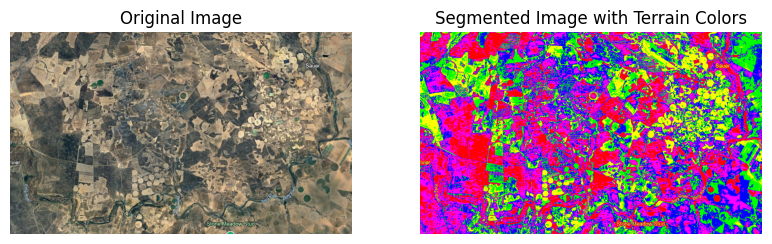

In [ ]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(segmented_image)
plt.title('Segmented Image with Terrain Colors')
plt.axis('off')

In [ ]:
Map.addLayer(clustered.randomVisualizer(), {}, 'K-Means Clustering Result')


Map.centerObject(aoi, 10)
Map

Map(bottom=28245.0, center=[25.59500675833021, 85.14999999999795], controls=(WidgetControl(options=['position'…

**Contour Detection**

Here, we apply Gaussian blur and edge detection to find contours on the image. These contours outline the different regions in the image, giving a sense of boundaries between different segments.




In [ ]:
blurred = cv2.GaussianBlur(image_rgb, (5, 5), 0)
edges = cv2.Canny(blurred, threshold1=100, threshold2=200)

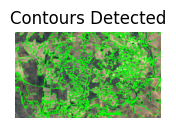

In [ ]:
contours, hierarchy = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contour_image = image_rgb.copy()  # Copy image for drawing contours
cv2.drawContours(contour_image, contours, -1, (0, 255, 0), 2)  # Draw contours in green

plt.subplot(1, 3, 3)
plt.imshow(contour_image)
plt.title('Contours Detected')
plt.axis('off')
plt.show()

**Feature Extraction: ORB Keypoints Detection**

ORB (Oriented FAST and Rotated BRIEF) is used to detect keypoints and compute descriptors. Keypoints are visual features that provide unique identifiers for different objects or textures in an image, helpful in image matching and classification.

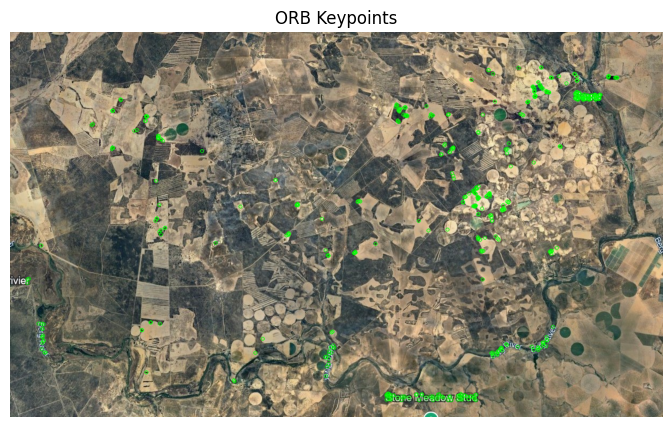

In [ ]:
orb = cv2.ORB_create()
keypoints, descriptors = orb.detectAndCompute(image_rgb, None)
image_with_keypoints = cv2.drawKeypoints(image_rgb, keypoints, None, color=(0, 255, 0))

# Display the ORB keypoints
plt.figure(figsize=(10, 5))
plt.imshow(image_with_keypoints)
plt.title('ORB Keypoints')
plt.axis('off')
plt.show()